## XY - Plane mapping density probability distribution function $P(X)$

#### Method 2: Integrating in the XY - Plane grid mapping in a cube in ($x$,$y$,$z$) and in a sphere in ($v_x$, $v_y$, $v_z$)

In [126]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from tqdm import tqdm
from matplotlib.colors import LogNorm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_X_to_E,
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND,
    surface_integral_P_X_CMND,
    trasformation_E_to_X
    )

In [106]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


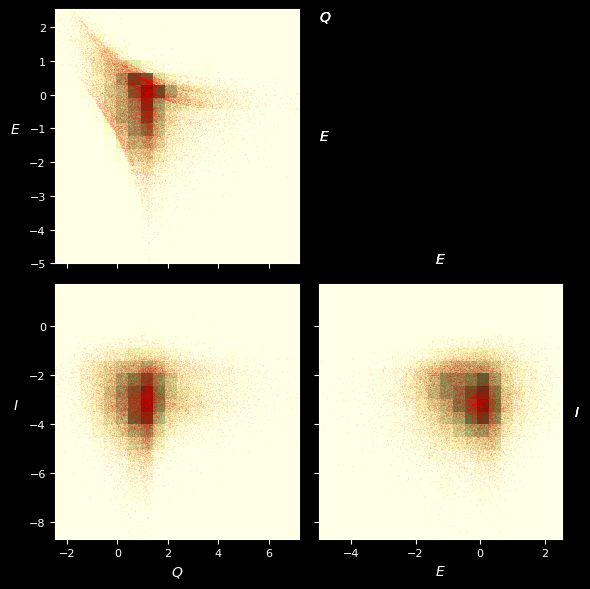

In [107]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [113]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()
    
    #not_sense_orbit = 0
    for idx in range(x_flat.size):
        #print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        #print('Orbital elements ', q, e, i, Omega, w, M, a)
        if q > 1.35 or e > 1: 
            #print("--------------NO SENSE ORBIT-----------------")
            #print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print('Orbital elements ', q, e, i, Omega, w, M, a)
            #not_sense_orbit += 1
            P.flat[idx] = 0
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    #print("------------PROBLEMATIC POINT------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)

                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                    #    print('--------------Nan value encounter-----------')
                    #    print(P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    
    return P.reshape(shape)#, not_sense_orbit

In [114]:
def sphere_surface_integral_P_X_CMND(
    r: np.array,
    dr: np.array,
    c_v: np.array,
    r_v: float,
    deg: int,
    q_max: int, 
    e_max: int, 
    i_max: int,
    mu=1, 
    F=mm.FitCMND
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    from numpy.polynomial.legendre import leggauss
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    x_vals = r[0] + dr[0] * nodes
    y_vals = r[1] + dr[1] * nodes
    z_vals = r[2] + dr[2] * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r_v / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, X, Y, Z = np.meshgrid(
        rho_vals, theta_vals, phi_vals, x_vals, y_vals, z_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_x, W_y, W_z = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    VX = c_v[0] + Rho * sin_theta * cos_phi
    VY = c_v[1] + Rho * sin_theta * sin_phi
    VZ = c_v[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r_v / 2.0) * (np.pi / 2.0) * np.pi * (dr[0] * dr[1] * dr[2])
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_x * W_y * W_z 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(X, Y, Z, VX, VY, VZ, q_max, e_max, i_max, mu, F=F)
        
    P_grid = P_output.reshape(total_weights.shape)
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.sum(weighted_values)
    
    return integral_result

In [116]:
x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5

z_center = 0.0

dx_cell, dy_cell = 0.05, 0.05
dz = 0.05
dr = np.array([dx_cell, dy_cell, dz])

vx_center = 0.01
vy_center = 0.01
vz_center = 0.01
center_vel = np.array([vx_center, vy_center, vz_center])

max_elements = (1.35, 1.0, np.pi) 

x_vals = np.arange(x_min, x_max + 2*dx_cell, 2*dx_cell)
y_vals = np.arange(y_min, y_max + 2*dy_cell, 2*dy_cell)

degree = 6

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((len(y_vals), len(x_vals)), dtype=dtype)

print("Starting probability mapping...")
for i, y_c in enumerate(tqdm(y_vals, desc="Y-axis progress")):
    for j, x_c in enumerate(x_vals):         

        a = (x_c**2 + y_c**2)**0.5
        Rvs = (2*mu/a)**0.5

        center_pos = np.array([x_c, y_c, z_center])
        print(center_pos, Rvs)

        try:
        # Calculate the integral for this hypervolume
            prob_value = sphere_surface_integral_P_X_CMND(
                center_pos, dr, 
                center_vel, Rvs, 
                degree, 
                q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], 
                mu=mu, 
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center_pos, center_vel)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = (prob_value, x_c, y_c)
        print(i, j, prob_value)
     
# Save to a .dat file
print("Mapping complete!")
np.save(f"data_results/method 2/XY_grid_map_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}.npy", probability_map)

Starting probability mapping...


Y-axis progress:   0%|          | 0/13 [00:00<?, ?it/s]

[0.4 0.4 0. ] 11.815857659239603
0 0 2.224132138781962e-06
[0.5 0.4 0. ] 11.105977287351562
0 1 2.9115158235958876e-06
[0.6 0.4 0. ] 10.465305465992945
0 2 3.1628482838559433e-06
[0.7 0.4 0. ] 9.897474830117899
0 3 3.095283049092286e-06
[0.8 0.4 0. ] 9.396805731671217
0 4 2.8955738162278664e-06
[0.9 0.4 0. ] 8.954880848032355
0 5 2.673702296440202e-06
[1.  0.4 0. ] 8.563242598309966
0 6 2.474803496157091e-06
[1.1 0.4 0. ] 8.214338649032527
0 7 2.31420847936919e-06
[1.2 0.4 0. ] 7.901740254597886
0 8 2.1986875103263385e-06
[1.3 0.4 0. ] 7.620084951633349
0 9 2.1630201054143332e-06
[1.4 0.4 0. ] 7.36493265350845
0 10 2.2448628550500778e-06
[1.5 0.4 0. ] 7.132610104796741
0 11 2.263700955510442e-06
[1.6 0.4 0. ] 6.920070502777386


Y-axis progress:   8%|▊         | 1/13 [13:05<2:37:02, 785.21s/it]

0 12 2.299336832207941e-06
[0.4 0.5 0. ] 11.105977287351562
1 0 3.4757499586554584e-06
[0.5 0.5 0. ] 10.568424375408519
1 1 5.642173980614459e-06
[0.6 0.5 0. ] 10.055884729567632
1 2 7.081366719874625e-06
[0.7 0.5 0. ] 9.581749555207647
1 3 7.4482130416213676e-06
[0.8 0.5 0. ] 9.14966605574271
1 4 7.120450182849824e-06
[0.9 0.5 0. ] 8.758430313068118
1 5 6.537538894328302e-06
[1.  0.5 0. ] 8.404758554950597
1 6 5.946481511477787e-06
[1.1 0.5 0. ] 8.084711580516228
1 7 5.4480534207676876e-06
[1.2 0.5 0. ] 7.794370915675791
1 8 5.085099977505846e-06
[1.3 0.5 0. ] 7.53012720413455
1 9 5.0118339452945115e-06
[1.4 0.5 0. ] 7.288777227035356
1 10 5.848641535369886e-06
[1.5 0.5 0. ] 7.067531339930947
1 11 4.625073896019496e-06
[1.6 0.5 0. ] 6.863982461783113


...

10 12 0.0002210690143483543
[0.4 1.5 0. ] 7.132610104796741
11 0 4.684418979213818e-06
[0.5 1.5 0. ] 7.067531339930947
11 1 1.2705566843775851e-05
[0.6 1.5 0. ] 6.9918583031747445
11 2 0.0001374314414877805
[0.7 1.5 0. ] 6.907407923651493
11 3 1.307137948472572e-05
[0.8 1.5 0. ] 6.8159796396786
11 4 6.8230276872575386e-06
[0.9 1.5 0. ] 6.719274577465963
11 5 1.2397888785528495e-05
[1.  1.5 0. ] 6.618840336389505
11 6 2.054290128875691e-05
[1.1 1.5 0. ] 6.516039681974884
11 7 3.142442678714715e-05
[1.2 1.5 0. ] 6.412038976466295
11 8 4.7443457861449424e-05
[1.3 1.5 0. ] 6.307811254778634
11 9 9.192426450333217e-05
[1.4 1.5 0. ] 6.204149026084955
11 10 0.0008240480871119544
[1.5 1.5 0. ] 6.1016826580523125
11 11 0.0004739793622875328
[1.6 1.5 0. ] 6.000901193631249


Y-axis progress:  92%|█████████▏| 12/13 [2:13:26<10:07, 607.41s/it]

11 12 0.002480304668287945
[0.4 1.6 0. ] 6.920070502777386
12 0 4.911982844958548e-06
[0.5 1.6 0. ] 6.863982461783113
12 1 2.391348599823087e-05
[0.6 1.6 0. ] 6.798404986416289
12 2 5.586613952839784e-05
[0.7 1.6 0. ] 6.724775420858804
12 3 3.2580401070352674e-06
[0.8 1.6 0. ] 6.6445450543573354
12 4 6.31373852742204e-06
[0.9 1.6 0. ] 6.559115370641024
12 5 1.150090060459638e-05
[1.  1.6 0. ] 6.469790913608042
12 6 1.9473846640102153e-05
[1.1 1.6 0. ] 6.377748768923337
12 7 3.140638818080191e-05
[1.2 1.6 0. ] 6.2840227308020005
12 8 5.543061391124041e-05
[1.3 1.6 0. ] 6.189499221320553
12 9 0.00021379996351275515
[1.4 1.6 0. ] 6.0949217804596785
12 10 0.00039906370031290924
[1.5 1.6 0. ] 6.000901193631249
12 11 0.00020346773890471455
[1.6 1.6 0. ] 5.907928829619803


Y-axis progress: 100%|██████████| 13/13 [2:22:46<00:00, 658.95s/it]

12 12 0.00044452816556736757
Mapping complete!


In [102]:
with open("data_results/method 2/PX_integration_XY_grid_xmin=0.4_xmax=1.5_ymin=-0.5_ymax=0.5.dat", "rb") as f:
    integral_grid = np.loadtxt(f, delimiter=',', skiprows=3)

with open("data_results/method 2/PX_integration_XY_grid_xmin=0.4_xmax=1.5_ymin=-0.5_ymax=0.5_2.npy", "rb") as f:
    integral_grid_2 = np.load(f, allow_pickle=False)

In [97]:
integral_grid_2['value']

array([[7.69654289e-07, 1.80198361e-06, 4.16079780e-06, 8.31539245e-06,
        1.40610920e-05, 2.07648955e-05, 2.84341741e-05, 3.95118210e-05,
        9.35291042e-05, 2.23623609e-04, 2.71645724e-05, 8.64300970e-06,
        9.44448144e-06],
       [8.48628660e-07, 2.07585099e-06, 4.35882462e-06, 7.66780601e-06,
        1.14883345e-05, 1.53140823e-05, 1.90968312e-05, 2.34829936e-05,
        3.08190093e-05, 8.82885994e-05, 2.73040361e-04, 3.20134600e-05,
        5.07878728e-06],
       [9.48289582e-07, 1.92864373e-06, 3.40208635e-06, 5.20431831e-06,
        7.06672738e-06, 8.83818865e-06, 1.05407497e-05, 1.23623998e-05,
        1.47510820e-05, 1.93354925e-05, 3.70074331e-05, 8.50040808e-05,
        3.04635641e-05],
       [8.01801678e-07, 1.23089935e-06, 1.83446553e-06, 2.54945313e-06,
        3.31369330e-06, 4.09850439e-06, 4.90895167e-06, 5.78514254e-06,
        6.82177270e-06, 8.26666872e-06, 1.09927922e-05, 1.78014372e-05,
        6.78204545e-05],
       [3.71173837e-07, 4.96623961e-

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_26132\3207372508.py:18: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


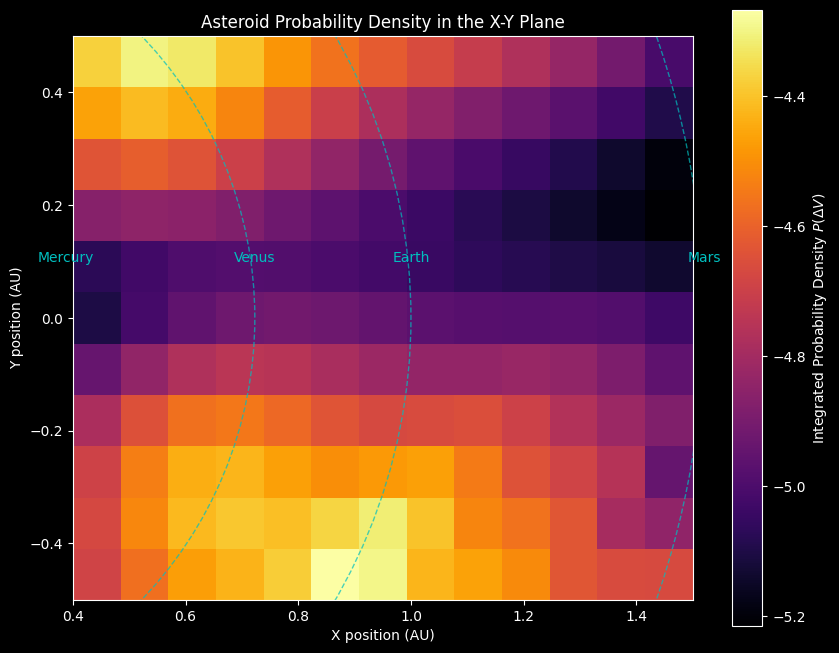

In [98]:
x_min, x_max = 0.4, 1.5
y_min, y_max = -0.5, 0.5

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
log_prob_map = np.log10(integral_grid)

im = ax.imshow(
    log_prob_map, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_26132\2057608524.py:18: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


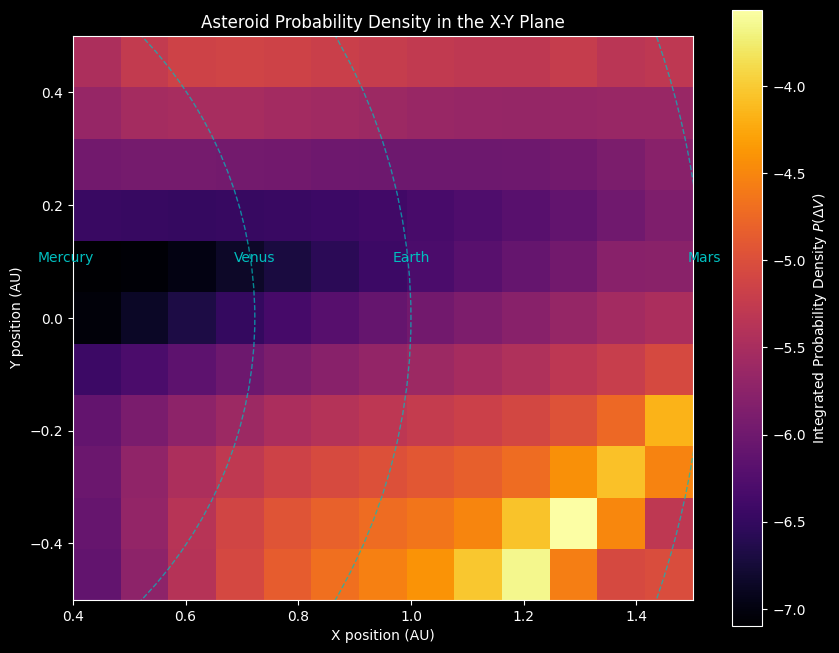

In [100]:
x_min, x_max = 0.4, 1.5
y_min, y_max = -0.5, 0.5

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
log_prob_map = np.log10(integral_grid_2['value'])

im = ax.imshow(
    log_prob_map, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_26132\57756887.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


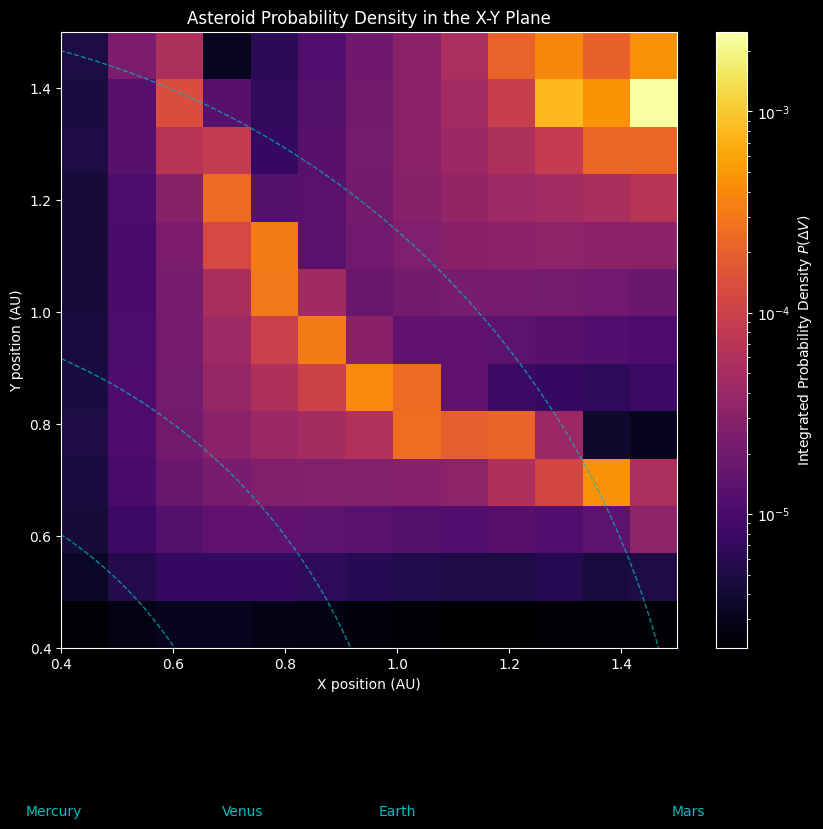

: 

In [ ]:
with open("data_results/method 2/XY_grid_map_xmin=0.4_xmax=1.5_ymin=0.4_ymax=1.5.npy", "rb") as f:
    integral_grid_3 = np.load(f, allow_pickle=False)

x_min, x_max = 0.4, 1.5
y_min, y_max = 0.4, 1.5

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
#log_prob_map = np.log10(integral_grid_3['value'])

im = ax.imshow(
    integral_grid_3['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

In [119]:
center_pos = np.array([1.5, 1.5, 0.0])
a = (center_pos[0]**2 + center_pos[1]**2)**0.5
Rvs = (2*mu/a)**0.5

In [121]:
center_pos = np.array([1.5, 1.5, 0.0])
a = (center_pos[0]**2 + center_pos[1]**2)**0.5
Rvs = (2*mu/a)**0.5

prob_value = sphere_surface_integral_P_X_CMND(
    center_pos, dr, 
    center_vel, Rvs, 
    degree, 
    q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], 
    mu=mu, 
    F=F
)
np.log10(prob_value)

-3.3242405676923035

In [123]:
prob_value

0.000473979362287763

In [122]:
center_pos = np.array([1.0, 1.0, 0.0])
a = (center_pos[0]**2 + center_pos[1]**2)**0.5
Rvs = (2*mu/a)**0.5

prob_value2 = sphere_surface_integral_P_X_CMND(
    center_pos, dr, 
    center_vel, Rvs, 
    degree, 
    q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], 
    mu=mu, 
    F=F
)
np.log10(prob_value2)

-4.519688305309766

In [124]:
prob_value2

3.022119928436643e-05